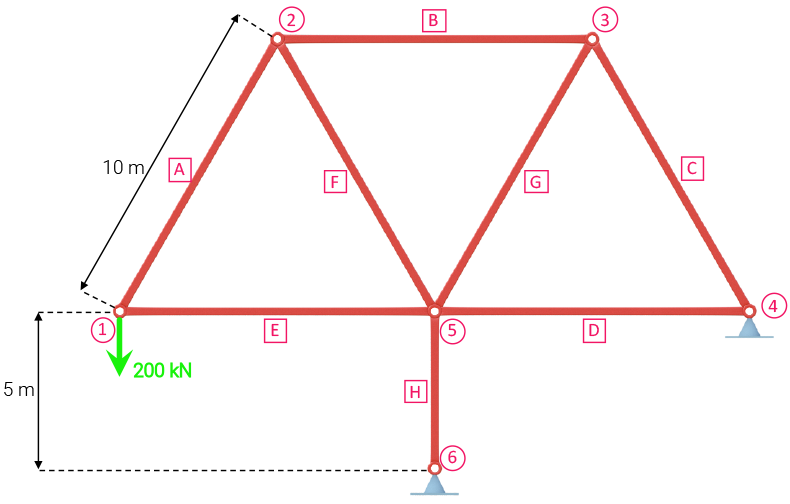

In [2]:
import numpy as np
import copy as cp
import math
import matplotlib.pyplot as plt

E=200*10**6   # kN/m2
A=0.005        # m2
L=10           # (m)for all members but 5m for member H
nDof= 12
restrainedDof=[7,8,11,12]

## Calculate global stiffness matrix

In [3]:
def calKg(E,A,L,theta):
    c=math.cos(theta)
    s=math.sin(theta)

    K11= (E*A/L)*np.array([[c**2,c*s],
                   [c*s,s**2]])
    K12= (E*A/L)*np.array([[-c**2,-c*s],
                   [-c*s,-s**2]])
    K21= (E*A/L)*np.array([[-c**2,-c*s],
                   [-c*s,-s**2]])
    K22= (E*A/L)*np.array([[c**2,c*s],
                   [c*s,s**2]])
    return[K11,K12,K21,K22]
    

In [4]:
[K11_12,K12_12,K21_12,K22_12]=calKg(E,A,L,1.0472)
[K11_15,K12_15,K21_15,K22_15]=calKg(E,A,L,0)
[K11_23,K12_23,K21_23,K22_23]=calKg(E,A,L,0)
[K11_25,K12_25,K21_25,K22_25]=calKg(E,A,L,5.23599)          # theta=300
[K11_34,K12_34,K21_34,K22_34]=calKg(E,A,L,5.23599)
[K11_35,K12_35,K21_35,K22_35]=calKg(E,A,L,4.18879)
[K11_45,K12_45,K21_45,K22_45]=calKg(E,A,L,3.1415926535)
[K11_56,K12_56,K21_56,K22_56]=calKg(E,A,5,4.71239)

In [5]:
print(np.round(K11_56,3))

[[ 0.00e+00 -2.04e-01]
 [-2.04e-01  2.00e+05]]


## Primary Stiffness Matrix of Structure

In [6]:
k11=K11_12
k12=K12_12
k13=np.zeros([2,2])
k14=np.zeros([2,2])
k15=K11_15
k16=np.zeros([2,2])

k21=K21_12
k22=K22_12+K11_23+K11_25
k23=K12_23
k24=np.zeros([2,2])
k25=K12_25
k26=np.zeros([2,2])

k31=np.zeros([2,2])
k32=K21_23
k33=K22_23+K11_34+K11_35
k34=K12_34
k35=K12_35
k36=np.zeros([2,2])

k41=np.zeros([2,2])
k42=np.zeros([2,2])
k43=K21_34
k44=K22_34+K11_45
k45=K12_45
k46= np.zeros([2,2])

k51=K21_15
k52=K21_25
k53=K21_35
k54=K21_45
k55=K22_15+K22_25+K22_35+K22_45+K11_56
k56=K12_56

k61=np.zeros([2,2])
k62=np.zeros([2,2])
k63=np.zeros([2,2])
k64=np.zeros([2,2])
k65=K21_56
k66=K22_56

r1= np.concatenate((k11,k12,k13,k14,k15,k16), axis=1)
r2= np.concatenate((k21,k22,k23,k24,k25,k26), axis=1)
r3= np.concatenate((k31,k32,k33,k34,k35,k36), axis=1)
r4= np.concatenate((k41,k42,k43,k44,k45,k46), axis=1)
r5= np.concatenate((k51,k52,k53,k54,k55,k56), axis=1)
r6= np.concatenate((k61,k62,k63,k64,k65,k66), axis=1)

Kp= np.concatenate((r1,r2,r3,r4,r5,r6), axis=0)
np.set_printoptions(linewidth=200)                              ## to adjust the whole row of the matrix in one line
print(np.round(Kp,3))

[[ 2.49997880e+04  4.33011480e+04 -2.49997880e+04 -4.33011480e+04  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+05  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 4.33011480e+04  7.50002120e+04 -4.33011480e+04 -7.50002120e+04  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.49997880e+04 -4.33011480e+04  1.49999982e+05 -2.35000000e-01 -1.00000000e+05 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -2.50001940e+04  4.33013820e+04  0.00000000e+00  0.00000000e+00]
 [-4.33011480e+04 -7.50002120e+04 -2.35000000e-01  1.50000018e+05 -0.00000000e+00 -0.00000000e+00  0.00000000e+00  0.00000000e+00  4.33013820e+04 -7.49998060e+04  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -1.00000000e+05 -0.00000000e+00  1.50000212e+05 -1.02000000e-01 -2.50001940e+04  4.33013820e+04 -2.50000180e+04 -4.33012800e+04  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.0000

## Extract Structure Stiffness matrix

In [7]:
restrainedIndex= [x-1 for x in restrainedDof]

# Reduce to structure stiffness matrix by deleting the rows and columns for restrained Dof
Ks=np.delete(Kp,restrainedIndex,0)
Ks=np.delete(Ks,restrainedIndex,1)
Ks=np.matrix(Ks)
print(np.round(Ks,3))

[[ 2.49997880e+04  4.33011480e+04 -2.49997880e+04 -4.33011480e+04  0.00000000e+00  0.00000000e+00  1.00000000e+05  0.00000000e+00]
 [ 4.33011480e+04  7.50002120e+04 -4.33011480e+04 -7.50002120e+04  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.49997880e+04 -4.33011480e+04  1.49999982e+05 -2.35000000e-01 -1.00000000e+05 -0.00000000e+00 -2.50001940e+04  4.33013820e+04]
 [-4.33011480e+04 -7.50002120e+04 -2.35000000e-01  1.50000018e+05 -0.00000000e+00 -0.00000000e+00  4.33013820e+04 -7.49998060e+04]
 [ 0.00000000e+00  0.00000000e+00 -1.00000000e+05 -0.00000000e+00  1.50000212e+05 -1.02000000e-01 -2.50000180e+04 -4.33012800e+04]
 [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -1.02000000e-01  1.49999788e+05 -4.33012800e+04 -7.49999820e+04]
 [-1.00000000e+05 -0.00000000e+00 -2.50001940e+04  4.33013820e+04 -2.50000180e+04 -4.33012800e+04  2.50000212e+05 -3.06000000e-01]
 [-0.00000000e+00 -0.00000000e+00  4.33013820e+04 -7.49998060e+04 -4.33012800e+04 -

In [8]:
U1=Ks.I*np.array([[0],[-200],[0],[0],[0],[0],[0],[0]])
U1_x1=U1[0,0]
U1_y1=U1[1,0]
U2_x2=U1[2,0]
U2_y2=U1[3,0]
U3_x3=U1[4,0]
U3_y3=U1[5,0]
U5_x5=U1[6,0]
U5_y5=U1[7,0]
U= np.matrix([[U1_x1],[U1_y1],[U2_x2],[U2_y2],[U3_x3],[U3_y3],[U5_x5],[U5_y5]])
print(U)

[[ 0.00230938]
 [-0.01866661]
 [-0.00808288]
 [-0.01000001]
 [-0.00577348]
 [-0.00066667]
 [ 0.00115469]
 [-0.002     ]]


## Reaction forces

In [9]:
UG= np.matrix([[U1_x1],[U1_y1],[U2_x2],[U2_y2],[U3_x3],[U3_y3],[0],[0],[U5_x5],[U5_y5],[0],[0]])
FG=np.matmul(Kp,UG)
FGclean=np.round(FG,decimals=1)
print(FGclean)


[[   0.]
 [-200.]
 [  -0.]
 [   0.]
 [   0.]
 [   0.]
 [   0.]
 [-200.]
 [   0.]
 [  -0.]
 [  -0.]
 [ 400.]]


## Element forces

In [11]:
def calcforce(E,A,L,theta,Ua,Ub):

    # Transformation matrix
    c=math.cos(theta)
    s=math.sin(theta)
    T=np.array([[c,s,0,0],
                [0,0,c,s]])

    disp=np.array([[Ua[0],Ua[1],Ub[0],Ub[1]]]).T
    disp_loc=np.matmul(T,disp)
    F_axial= (E*A/L)*(disp_loc[1]-disp_loc[0])

    return F_axial

F12= calcforce(E,A,L,1.0472,[U1_x1,U1_y1],[U2_x2,U2_y2])
F23= calcforce(E,A,L,0,[U2_x2,U2_y2],[U3_x3,U3_y3])
F34= calcforce(E,A,L,5.23599,[U3_x3,U3_y3],[0,0])
F45= calcforce(E,A,L,3.14159,[0,0],[U5_x5,U5_y5])
F15= calcforce(E,A,L,0,[U1_x1,U1_y1],[U5_x5,U5_y5])
F25= calcforce(E,A,L,5.23599,[U2_x2,U2_y2],[U5_x5,U5_y5])
F35= calcforce(E,A,L,4.18879,[U3_x3,U3_y3],[U5_x5,U5_y5])
F56= calcforce(E,A,5,4.71239,[U5_x5,U5_y5],[0,0])

elementForce=[F12,F23,F34,F45,F15,F25,F35,F56]
print(np.round(elementForce,2))

print(f"The Horizontal Displacement at Node 1 is: {U1_x1:.4f}m (to the right)")
print(f"The Vertical Displacement at Node 1 is: {U1_y1:.4f}m (downwards)")

[[ 230.94]
 [ 230.94]
 [ 230.94]
 [-115.47]
 [-115.47]
 [-230.94]
 [-230.94]
 [-400.  ]]
The Horizontal Displacement at Node 1 is: 0.0023m (to the right)
The Vertical Displacement at Node 1 is: -0.0187m (downwards)


## Plotting

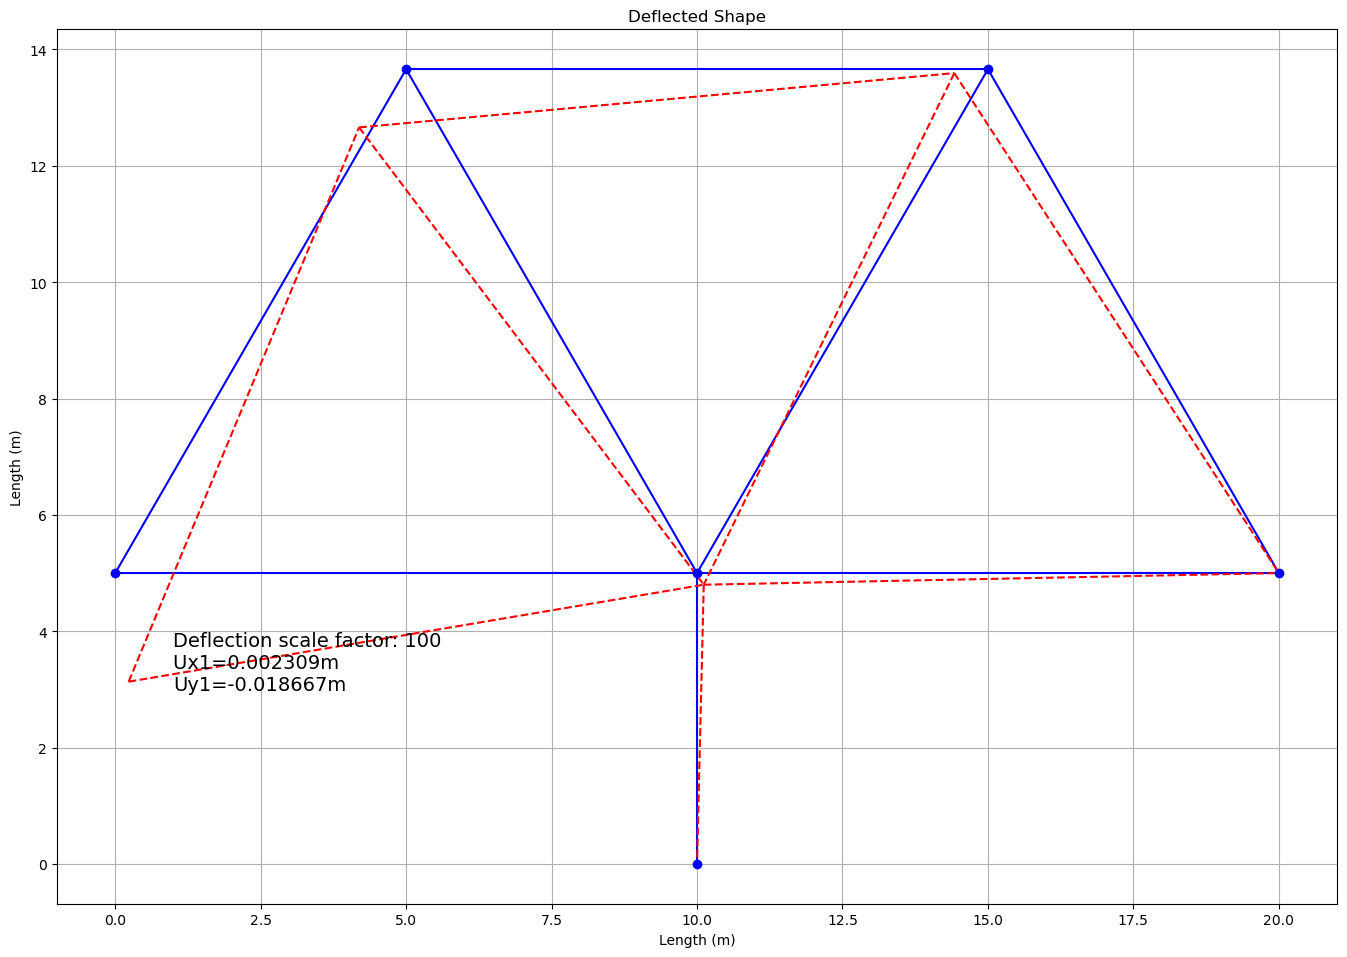

In [15]:
# Location of nodes


xFact= 100 ## using this to multiply the disp so as to view the very small disp in our figure

label="Deflection scale factor: "+str(xFact)+"\nUx1="+str(round(U1_x1,6))+"m \nUy1="+str(round(U1_y1,6))+"m"

fig= plt.figure()
axes= fig.add_axes([0,0,2,2])
fig.gca().set_aspect('equal',adjustable='box')


# Element A: Node 1 [0, 5] to Node 2 [13, 8.66]
axes.plot([0, 5], [5, 13.66], 'b')
# Element E: Node 1 [0, 5] to Node 5 [10, 5]
axes.plot([0, 10], [5, 5], 'b')

# Element B: Node 2 [5, 8.66] to Node 3 [15, 13.66]
axes.plot([5, 15], [13.66, 13.66], 'b')
# Element F: Node 2 [5, 13.66] to Node 5 [10, 5]
axes.plot([5, 10], [13.66, 5], 'b')

# Element C: Node 3 [15, 13.66] to Node 4 [20, 5]
axes.plot([15, 20], [13.66, 5], 'b')
# Element G: Node 3 [15, 8.66] to Node 5 [10, 5]
axes.plot([15, 10], [13.66, 5], 'b')

# Element D: Node 5 [10, 5] to Node 4 [20, 5]
axes.plot([10, 20], [5, 5], 'b')
# Element H: Node 5 [10, 5] to Node 6 [10, 0]
axes.plot([10, 10], [5, 0], 'b')

axes.plot([0 + U1_x1*xFact, 5 + U2_x2*xFact], [5 + U1_y1*xFact, 13.66 + U2_y2*xFact], '--r')  # A
axes.plot([0 + U1_x1*xFact, 10 + U5_x5*xFact], [5 + U1_y1*xFact, 5 + U5_y5*xFact], '--r')# E

axes.plot([5 + U2_x2*xFact, 15 + U3_x3*xFact], [13.66 + U2_y2*xFact, 13.66 + U3_y3*xFact], '--r') # B
axes.plot([5 + U2_x2*xFact, 10 + U5_x5*xFact], [13.66 + U2_y2*xFact, 5 + U5_y5*xFact], '--r') # F

axes.plot([15 + U3_x3*xFact, 20], [13.66 + U3_y3*xFact, 5], '--r') # C  
axes.plot([15 + U3_x3*xFact, 10 + U5_x5*xFact], [13.66 + U3_y3*xFact, 5 + U5_y5*xFact], '--r') #G

axes.plot([10 + U5_x5*xFact, 20], [5 + U5_y5*xFact, 5], '--r') #D
axes.plot([10 + U5_x5*xFact, 10], [5 + U5_y5*xFact, 0], '--r') #H

# Original Node Positions
axes.plot([0], [5], 'bo')     # Node 1
axes.plot([5], [13.66], 'bo') # Node 2
axes.plot([15], [13.66], 'bo')# Node 3
axes.plot([20], [5], 'bo') # Node 4
axes.plot([10], [5], 'bo')     # Node 5
axes.plot([10], [0], 'bo')     # Node 6

plt.text(1,4, label, fontsize=14,va="top")
axes.grid()
axes.set_title("Deflected Shape")
axes.set_xlabel("Length (m)")
axes.set_ylabel("Length (m)")
plt.show()